<a href="https://colab.research.google.com/github/brahmanbhavika06-sketch/my-colab-code/blob/main/Session_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import Libraries
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs

# Create Synthetic Dataset
X, y = make_blobs(
    n_samples=500,
    centers=4,
    cluster_std=0.70,
    random_state=42
)
# Convert into DataFrame
df = pd.DataFrame(X, columns=["Feature1", "Feature2"])

# Display first 10 rows
print(df.head(10))

# Shape
print("Shape:", df.shape)

   Feature1  Feature2
0 -8.033836  6.831299
1 -8.767448 -6.918116
2  6.172741  1.407361
3 -2.783673  7.989826
4 -6.038777 -7.165762
5 -6.298392 -7.479368
6 -7.046269  7.256281
7 -6.690307 -6.915276
8  3.892545  1.873504
9 -7.317000 -6.861846
Shape: (500, 2)


In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

print(X_scaled[:5])

[[-0.88847363  0.62990684]
 [-1.02890768 -1.56287499]
 [ 1.83106858 -0.23511276]
 [ 0.11655663  0.81467072]
 [-0.5065627  -1.60237008]]


In [3]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

print(df.head(10))

   Feature1  Feature2  Cluster
0 -8.033836  6.831299        1
1 -8.767448 -6.918116        2
2  6.172741  1.407361        0
3 -2.783673  7.989826        1
4 -6.038777 -7.165762        2
5 -6.298392 -7.479368        2
6 -7.046269  7.256281        1
7 -6.690307 -6.915276        2
8  3.892545  1.873504        0
9 -7.317000 -6.861846        2


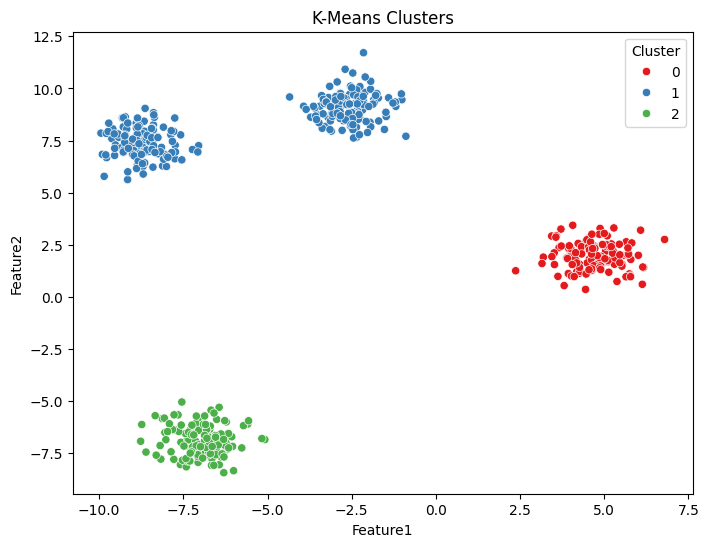

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Feature1",
    y="Feature2",
    hue="Cluster",
    palette="Set1"
)

plt.title("K-Means Clusters")
plt.xlabel("Feature1")
plt.ylabel("Feature2")

plt.show()

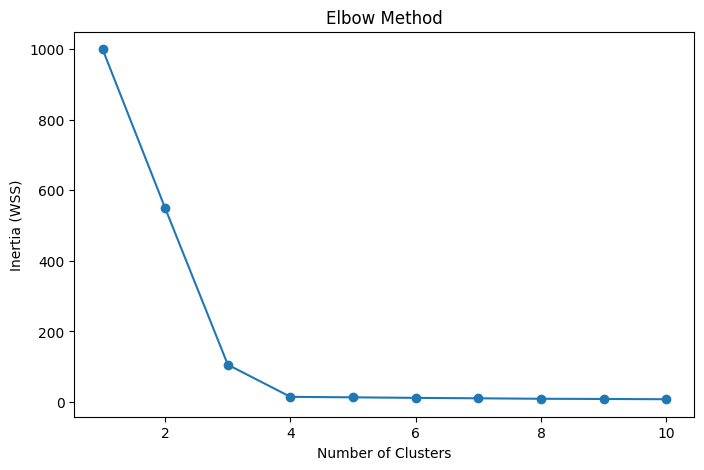

In [5]:
wss = []

for k in range(1,11):

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    model.fit(X_scaled)

    wss.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wss, marker="o")

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia (WSS)")
plt.title("Elbow Method")

plt.show()

In [6]:
final_model = KMeans(
    n_clusters=4,
    random_state=42
)

final_cluster = final_model.fit_predict(X_scaled)

df["Final_Cluster"] = final_cluster

print(df["Final_Cluster"].value_counts())

Final_Cluster
1    125
2    125
0    125
3    125
Name: count, dtype: int64


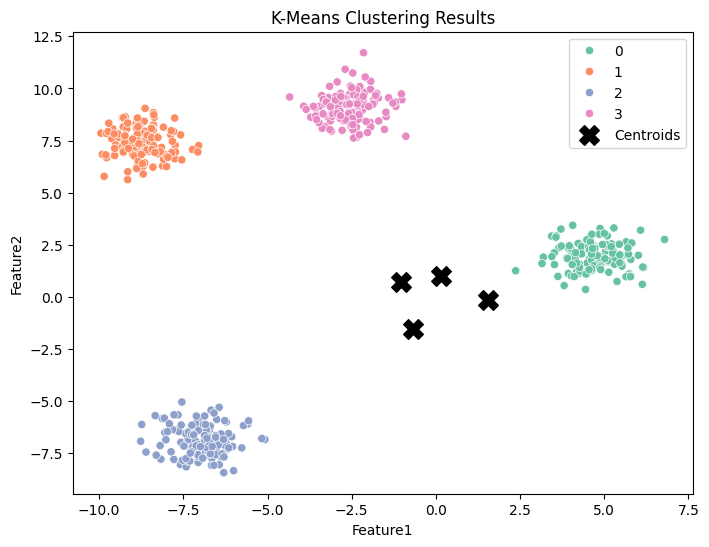

In [7]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Feature1",
    y="Feature2",
    hue="Final_Cluster",
    palette="Set2"
)

plt.scatter(
    final_model.cluster_centers_[:,0],
    final_model.cluster_centers_[:,1],
    color="black",
    marker="X",
    s=200,
    label="Centroids"
)

plt.title("K-Means Clustering Results")

plt.legend()

plt.show()

In [11]:
from sklearn.datasets import load_iris

iris = load_iris()

iris_df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

print(iris_df.head())

scaler = StandardScaler()

iris_scaled = scaler.fit_transform(iris_df)

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

iris_df["Cluster"] = kmeans.fit_predict(iris_scaled)

print(iris_df["Cluster"].value_counts())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
Cluster
0    96
1    33
2    21
Name: count, dtype: int64


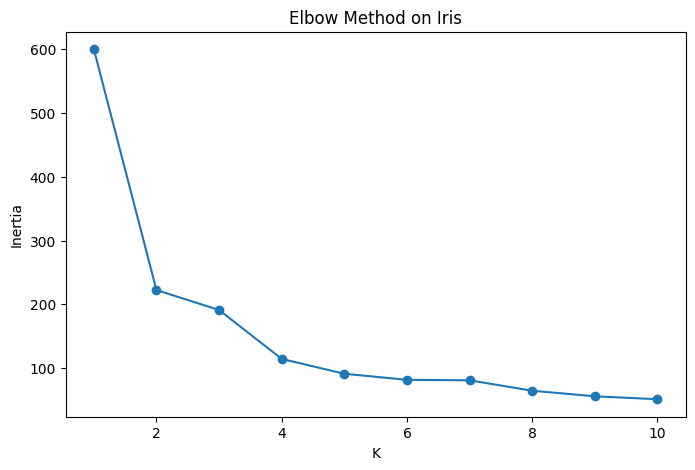

Final Cluster
0    96
1    33
2    21
Name: count, dtype: int64


In [29]:
wss = []

for k in range(1,11):
    km = KMeans(
        n_clusters=k,
        random_state=42
    )
    km.fit(iris_scaled)
    wss.append(km.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wss, marker="o")

plt.xlabel("K")
plt.ylabel("Inertia")

plt.title("Elbow Method on Iris")

plt.show()
final_kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

iris_df["Final Cluster"] = final_kmeans.fit_predict(iris_scaled)

print(iris_df["Final Cluster"].value_counts())

In [ ]:
Q10. Mini Project – Complete Clustering Pipeline

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
(150, 4)


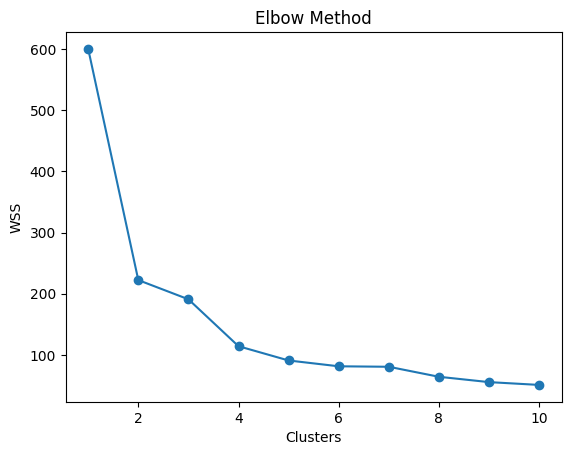

Cluster
0    96
1    33
2    21
Name: count, dtype: int64


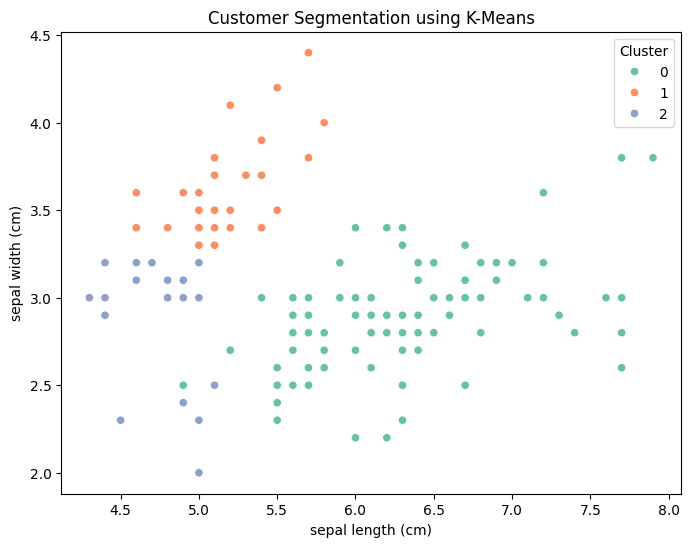

In [26]:
# Step 1
from sklearn.datasets import load_iris

iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

print(df.head())
print(df.shape)



# Step 2
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)



# Step 3

wss=[]

for i in range(1,11):

    km=KMeans(
        n_clusters=i,
        random_state=42
    )

    km.fit(scaled_data)

    wss.append(km.inertia_)

plt.plot(range(1,11),wss,marker="o")

plt.xlabel("Clusters")

plt.ylabel("WSS")

plt.title("Elbow Method")

plt.show()





# Step 4

model=KMeans(
    n_clusters=3,
    random_state=42
)

df["Cluster"]=model.fit_predict(scaled_data)

print(df["Cluster"].value_counts())


# Step 5

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x=df.columns[0],
    y=df.columns[1],
    hue="Cluster",
    palette="Set2"
)

plt.title("Customer Segmentation using K-Means")

plt.show()